## Latency Metrics

In [1]:
from experiment_analysis import load_experiment_latencies

# Load experiment 3 from ./experiments/3
df = load_experiment_latencies(exp_id=1)

df.head()
df.describe(percentiles=[0.5, 0.9, 0.99])[[
    "end_to_end_s",
    "server_roundtrip_s",
    "router_queue_s",
    "vllm_compute_s",
]]


../experiments/1/logs.json


,end_to_end_s,server_roundtrip_s,router_queue_s,vllm_compute_s
count,200.000000,200.000000,200.000000,200.000000
mean,57.795467,56.181367,25.247258,25.497478
std,23.565479,22.952920,21.505428,23.440518
min,11.520083,11.103379,0.048732,0.491463
50%,61.875985,59.775285,24.027480,18.032927
90%,84.396536,82.213598,56.068665,62.693310
99%,112.464290,109.601380,64.114528,96.593244
max,119.024286,116.272725,64.920739,103.313918


In [2]:
df

,idx,req_id,send_failed,end_to_end_s,model_latency_s,finish_reason,prompt_tokens,completion_tokens,total_tokens,serving_pod,...,applied_time_offset_s,client_to_router_s,router_queue_s,router_to_sidecar_s,sidecar_queue_s,vllm_compute_s,sidecar_post_s,sidecar_to_router_s,router_post_result_s,server_roundtrip_s
0,36,98c124a6afae45a390cd8ca919f1c8ff,False,11.520083,11.066161,stop,381,3,384,None,...,NaN,0.416704,0.433301,0.015895,0.000116,11.067440,0.000092,0.002458,0.000765,11.103379
1,12,d088e191fdcc4c69ad5d1e13b5cb8643,False,11.842530,11.608371,stop,319,3,322,None,...,NaN,0.177175,0.211616,0.016350,0.000990,11.609356,0.000055,0.003003,0.001142,11.665354
2,7,82c1ff2cd40e4a8f9ba97da68b4bd7fb,False,11.903915,11.638632,stop,457,4,461,None,...,NaN,0.085120,0.230718,0.016350,0.014168,11.639703,0.000048,0.002461,0.000406,11.818795
3,4,31cd5d2f81ed418d9f0e41607fecda7c,False,14.100425,13.847667,stop,450,3,453,None,...,NaN,0.112029,0.228019,0.015296,0.000104,13.849318,0.000053,0.007111,0.000510,13.988396
4,33,9fd355c57efe46a78bf9cf4742e14718,False,14.043286,13.596580,stop,297,3,300,None,...,NaN,0.404413,0.422870,0.015266,0.000103,13.598464,0.000065,0.004795,0.001712,13.638873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,38,c73683fb920b462783383d011ea1c5c6,False,103.935939,103.312795,length,413,2048,2461,None,...,NaN,0.464399,0.590321,0.015841,0.011887,103.313918,0.000147,0.003269,0.000547,103.471540
196,142,4cdd4cea7d2b43bdbe985033db58c39b,False,104.593334,42.861517,stop,276,1482,1758,None,...,NaN,3.253358,61.726610,0.000676,0.000038,42.862381,0.000082,0.003091,0.000450,101.339975
197,119,5a2f0cfd42c643dd9ac5131f3671781a,False,112.447543,57.699725,stop,380,1887,2267,None,...,NaN,2.863583,54.741109,0.000721,0.000050,57.700992,0.000177,0.003970,0.000518,109.583960
198,137,925121e7ea7044cd9d7862b0bfeef1ba,False,114.122233,62.404224,length,382,2048,2430,None,...,NaN,2.796322,51.712594,0.000625,0.000039,62.405280,0.000127,0.003056,0.000505,111.325910


In [3]:
from experiment_analysis import experiments_from_series

In [4]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# choose which series you want
series_ids = [35]

experiments = experiments_from_series(series_ids)

print(experiments)
# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)

    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison


[141, 142, 143, 144]
../experiments/141/logs.json
../experiments/142/logs.json
../experiments/143/logs.json
../experiments/144/logs.json


,exp141_end_to_end_s,exp142_end_to_end_s,exp143_end_to_end_s,exp144_end_to_end_s
count,9976.000000,9964.000000,9974.000000,9962.000000
mean,64.893580,116.182015,102.118739,117.589185
std,58.164109,113.906219,105.089049,112.262727
min,0.196312,0.184058,0.193541,0.190909
50%,62.785099,81.918198,71.895514,85.721957
90%,103.711205,308.122208,235.805917,302.643339
99%,319.234071,426.475336,519.509373,420.147813
max,2319.922843,651.953505,776.306737,639.709471


[141, 142, 143, 144]
../experiments/141/logs.json
[exp 141] corrected_requests=0/9976
../experiments/142/logs.json
[exp 142] corrected_requests=0/9964
../experiments/143/logs.json
[exp 143] corrected_requests=0/9974
../experiments/144/logs.json
[exp 144] corrected_requests=0/9962

Average latencies per experiment:

[time_offsets] APPLY_TIME_OFFSETS=True

Experiment 141:
  client_to_router_s          :    0.004 s
  router_queue_s              :   43.470 s
  router_to_sidecar_s         :    0.001 s
  sidecar_queue_s             :    0.001 s
  vllm_compute_s              :   21.414 s
  sidecar_post_s              :    0.000 s
  sidecar_to_router_s         :    0.006 s
  router_post_result_s        :      nan s
  SUM (components)            :   64.896 s

  Router post-result breakdown:
    router_result_handler_s   : 0.000001 s
    router_wakeup_s           :      nan s
    router_response_build_s   :      nan s
    router_after_return_stamp_s:      nan s
    SUM (post breakdown)      : 0.

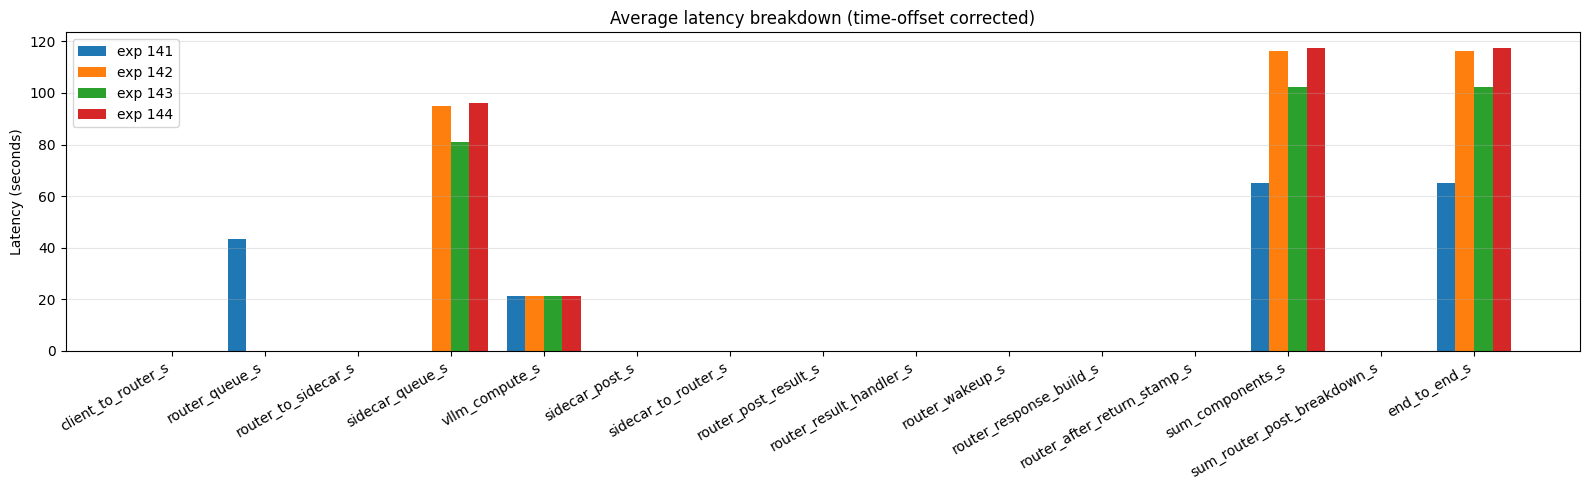

In [5]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import numpy as np

# ---- choose experiments ----
series_ids = [35]
experiments = experiments_from_series(series_ids)
print(experiments)
# ---------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# Non-overlapping latency components (base)
component_cols = [
    "client_to_router_s",
    "router_queue_s",
    "router_to_sidecar_s",
    "sidecar_queue_s",
    "vllm_compute_s",
    "sidecar_post_s",
    "sidecar_to_router_s",
    "router_post_result_s",
]

# router post-result breakdown (should sum ~ router_post_result_s when present)
router_post_breakdown_cols = [
    "router_result_handler_s",     # time spent inside /result handler (very small normally)
    "router_wakeup_s",             # waiter unblocked -> wait_for_result returns
    "router_response_build_s",     # build/merge trace/rename fields
    "router_after_return_stamp_s", # any last stamp after response object prepared (if you keep it)
]

extra_component_cols = [
    # keep empty unless you explicitly expose more metrics columns
]

e2e_col = "end_to_end_s"

plot_cols = (
    component_cols
    + router_post_breakdown_cols
    + extra_component_cols
    + ["sum_components_s", "sum_router_post_breakdown_s", e2e_col]
)

avg_by_exp = {}

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        apply_time_offset_correction=APPLY_TIME_OFFSETS,
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    # Base component means
    comp_means = df.reindex(columns=component_cols).mean(numeric_only=True)
    sum_components = float(comp_means.sum(skipna=True))

    # Router post breakdown means
    post_means = df.reindex(columns=router_post_breakdown_cols).mean(numeric_only=True)
    sum_post_breakdown = float(post_means.sum(skipna=True))

    # Optional extras
    extra_means = df.reindex(columns=extra_component_cols).mean(numeric_only=True)

    e2e_mean = float(df[e2e_col].mean()) if e2e_col in df.columns else float("nan")

    row = {}

    for k in component_cols:
        row[k] = float(comp_means.get(k, np.nan))

    for k in router_post_breakdown_cols:
        row[k] = float(post_means.get(k, np.nan))

    for k in extra_component_cols:
        row[k] = float(extra_means.get(k, np.nan))

    row["sum_components_s"] = sum_components
    row["sum_router_post_breakdown_s"] = sum_post_breakdown
    row[e2e_col] = e2e_mean

    avg_by_exp[exp_id] = row

# ---- print numbers ----
print("\nAverage latencies per experiment:\n")
print(f"[time_offsets] APPLY_TIME_OFFSETS={APPLY_TIME_OFFSETS}\n")

for exp_id in experiments:
    r = avg_by_exp[exp_id]
    print(f"Experiment {exp_id}:")

    for k in component_cols:
        print(f"  {k:28s}: {r[k]:8.3f} s")

    print(f"  {'SUM (components)':28s}: {r['sum_components_s']:8.3f} s")
    print()

    print("  Router post-result breakdown:")
    for k in router_post_breakdown_cols:
        print(f"    {k:26s}: {r[k]:8.6f} s")
    print(f"    {'SUM (post breakdown)':26s}: {r['sum_router_post_breakdown_s']:8.6f} s")

    base_post = r.get("router_post_result_s", np.nan)
    if not (np.isnan(base_post) or np.isnan(r["sum_router_post_breakdown_s"])):
        diff = base_post - r["sum_router_post_breakdown_s"]
        print(f"    {'router_post_result_s':26s}: {base_post:8.6f} s")
        print(f"    {'DIFF (base - sum)':26s}: {diff:8.6f} s")
    print()

    print(f"  {e2e_col:28s}: {r[e2e_col]:8.3f} s")
    print()

# ---- grouped bar plot ----
labels = plot_cols
x = np.arange(len(labels))
width = 0.8 / max(1, len(experiments))

plt.figure(figsize=(16, 5))

for i, exp_id in enumerate(experiments):
    vals = [avg_by_exp[exp_id].get(k, np.nan) for k in labels]
    plt.bar(x + i * width, vals, width, label=f"exp {exp_id}")

plt.xticks(
    x + width * (len(experiments) - 1) / 2,
    labels,
    rotation=30,
    ha="right"
)
plt.ylabel("Latency (seconds)")
plt.title(
    "Average latency breakdown (time-offset corrected)"
    if APPLY_TIME_OFFSETS
    else "Average latency breakdown (raw clocks)"
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


../experiments/1/logs.json


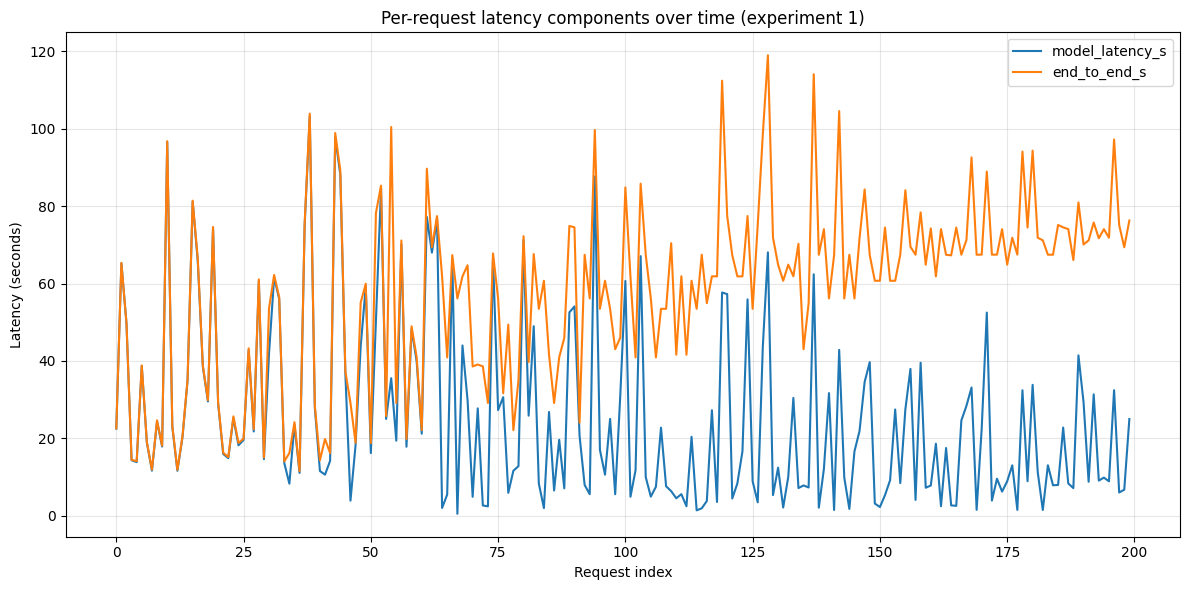

In [6]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiment ----
exp_id = 1
# ---------------------------

# Load and order by request index (or any monotonic field you prefer)
df = load_experiment_latencies(exp_id=exp_id).sort_values("idx").reset_index(drop=True)

# X-axis: request index (0, 1, 2, ...)
x = df["idx"]

# Latency metrics to plot over time
latency_cols = [
    "model_latency_s",
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "router_to_sidecar_s",
    # "sidecar_queue_s",
    # "vllm_compute_s",
]

plt.figure(figsize=(12, 6))

for col in latency_cols:
    if col in df.columns:
        plt.plot(x, df[col], label=col)

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(f"Per-request latency components over time (experiment {exp_id})")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[141, 142, 143, 144]
../experiments/141/logs.json
[exp 141] corrected_requests=0/9976
../experiments/142/logs.json
[exp 142] corrected_requests=0/9964
../experiments/143/logs.json
[exp 143] corrected_requests=0/9974
../experiments/144/logs.json
[exp 144] corrected_requests=0/9962


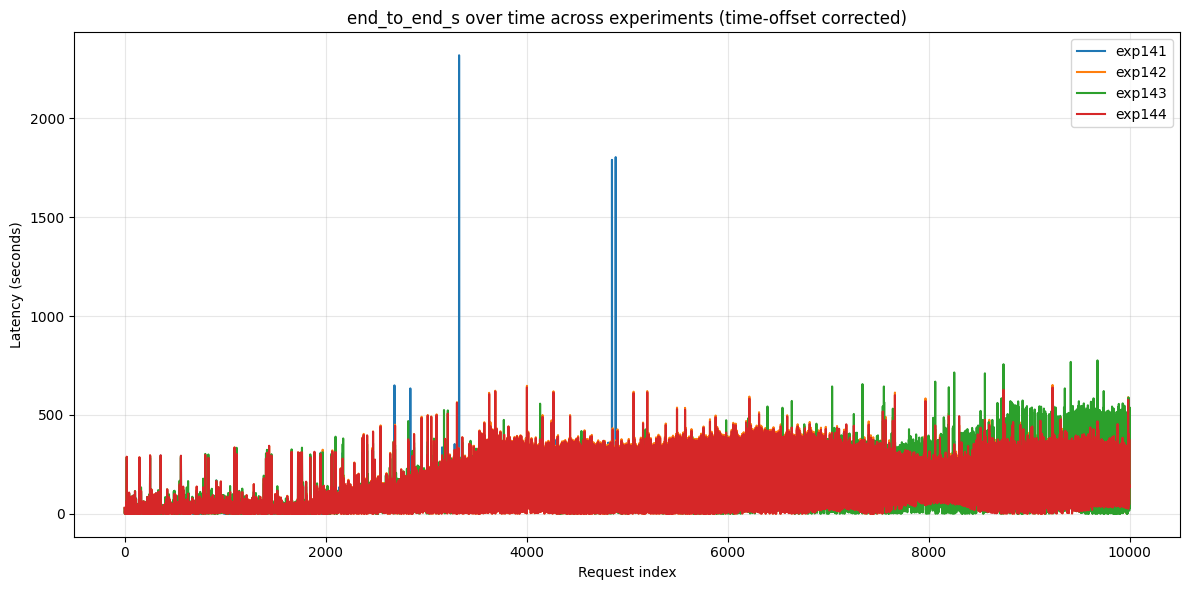

In [7]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
series_ids = [35]
experiments = experiments_from_series(series_ids)
# experiments = [142]
print(experiments)
# ----------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# ---- choose ONE metric (uncomment exactly one) ----
metric = "end_to_end_s"          # total client → router → server → client
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
#metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
    + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Throughput Metrics

In [8]:
from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
series_ids = [35]

experiments = experiments_from_series(series_ids)

print(experiments)
# ----------------------------------------------

# Prometheus metric columns of interest
# (these are the fields inside each "samples" object in metrics.jsonl)
cols = [
    "gen_tokens_per_sec",
    # "prefill_tokens_per_sec",
    # "requests_running",
    # "requests_waiting",
    # "request_success_per_sec",
    # "request_failure_per_sec",
    # "preemptions_per_sec",
    # "gpu_kv_cache_usage_frac",
    # "cpu_kv_cache_usage_frac",
    #
    # vLLM latency hist averages (if your vLLM exposes them)
    "ttft_seconds_avg",
    "tpot_seconds_avg",
    # "e2e_latency_seconds_avg",
    # "queue_time_seconds_avg",
    # "inference_time_seconds_avg",
    # "prefill_time_seconds_avg",
    # "decode_time_seconds_avg",
    #
    # token distribution hists (averages)
    # "request_prompt_tokens_avg",
    # "request_generation_tokens_avg",
    # "request_max_generation_tokens_avg",
    #
    # spec decode (optional)
    # "spec_tokens_accepted_per_sec",
    # "spec_tokens_draft_per_sec",
    # "spec_tokens_emitted_per_sec",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    # Option 1 (simple): pool all instances together, treat each (tick,instance) as a sample
    # Option 2 (cluster view): sum across instances per tick, then describe the per-tick totals
    # Choose one; default below is cluster view because it's usually what you want when comparing runs.

    # ---- CLUSTER VIEW (recommended): sum across instances per tick ----
    # keeps time granularity, avoids overweighting runs with more instances in the file
    agg = prom.groupby("ts")[cols].sum(min_count=1).reset_index()

    # Describe only selected cols
    summary = (
        agg[cols]
        .describe(percentiles=percentiles)
        .add_prefix(f"exp{exp_id}_")
    )
    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison


[141, 142, 143, 144]


,exp141_gen_tokens_per_sec,exp141_ttft_seconds_avg,exp141_tpot_seconds_avg,exp142_gen_tokens_per_sec,exp142_ttft_seconds_avg,exp142_tpot_seconds_avg,exp143_gen_tokens_per_sec,exp143_ttft_seconds_avg,exp143_tpot_seconds_avg,exp144_gen_tokens_per_sec,exp144_ttft_seconds_avg,exp144_tpot_seconds_avg
count,3028.000000,2836.000000,3027.000000,3247.000000,3066.000000,3246.000000,3322.000000,3215.000000,3320.000000,3242.000000,3059.000000,3240.000000
mean,1638.820723,2.321968,0.273691,1525.464347,2.201629,0.258475,1488.803386,2.098145,0.251674,1534.606706,2.205696,0.260278
std,396.972416,0.514040,0.037003,477.968351,0.670122,0.065204,499.446362,0.750625,0.071319,466.575648,0.634036,0.062411
min,0.000000,0.100324,0.026860,0.000000,0.107769,0.026856,0.000000,0.122327,0.028639,0.000000,0.135153,0.027876
50%,1761.344828,2.279156,0.282391,1700.551724,2.223789,0.279814,1698.706897,2.236797,0.279184,1702.982759,2.226888,0.280250
90%,1830.258621,2.811422,0.292998,1800.234483,2.875434,0.290124,1794.234483,2.885398,0.290161,1805.068966,2.855149,0.290441
99%,1888.796552,3.575630,0.303101,1854.857931,4.065780,0.303930,1874.084138,3.380404,0.294704,1861.239655,3.602032,0.300501
max,1943.448276,9.312065,0.315113,1883.586207,5.020578,0.313733,1893.275862,4.313156,0.302410,1880.275862,5.027376,0.412952


In [9]:
# Split the sum and mean group based on metric characteristics.
# SLO violation for TTFT and TPOT, can be customised based on the target SLO. For Qwen3-8B model, assume the SLO for TTFT is 500ms, for TPOT is 50 ms

from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
series_ids = [35]

experiments = experiments_from_series(series_ids)
print(experiments)
# ----------------------------------------------

# Prometheus metric columns of interest
# (these are the fields inside each "samples" object in metrics.jsonl)

# aggregated by SUM across instances per tick
sum_cols = [
    "gen_tokens_per_sec",
    # "prefill_tokens_per_sec",
    # "requests_running",       # sum = cluster total queue depth; use mean if single-instance or want per-instance avg
    # "requests_waiting",       # same as above
    # "request_success_per_sec",
    # "request_failure_per_sec",
    # "preemptions_per_sec",
]

# aggregated by MEAN across instances per tick
# (these are pre-averaged histograms inside vLLM)
mean_cols = [
    # vLLM latency hist averages (if your vLLM exposes them)
    "ttft_seconds_avg",
    "tpot_seconds_avg",
    # "e2e_latency_seconds_avg",
    # "queue_time_seconds_avg",
    # "inference_time_seconds_avg",
    # "prefill_time_seconds_avg",
    # "decode_time_seconds_avg",

    # # token distribution hists (averages)
    # "request_prompt_tokens_avg",
    # "request_generation_tokens_avg",
    # "request_max_generation_tokens_avg",

    # # spec decode (optional)
    # "spec_tokens_accepted_per_sec",  # debatable: could be sum if you want cluster total
    # "spec_tokens_draft_per_sec",
    # "spec_tokens_emitted_per_sec",

    # "gpu_kv_cache_usage_frac",
    # "cpu_kv_cache_usage_frac",
]

percentiles = [0.5, 0.9, 0.99]

# SLO thresholds
TTFT_SLO_S = 0.500  # 500ms in seconds
TPOT_SLO_S = 0.050  # 50ms in seconds

summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    # ---- CLUSTER VIEW (recommended): sum across instances per tick ----
    valid_sum_cols  = [c for c in sum_cols  if c in prom.columns]
    valid_mean_cols = [c for c in mean_cols if c in prom.columns]

    missing = set(sum_cols + mean_cols) - set(prom.columns)
    if missing:
        print(f"[WARN] exp{exp_id}: columns not found in prom, skipping: {missing}")

    agg_sum  = prom.groupby("ts")[valid_sum_cols].sum(min_count=1).reset_index()
    agg_mean = prom.groupby("ts")[valid_mean_cols].mean().reset_index()
    agg = agg_sum.merge(agg_mean, on="ts", how="outer")

    # Describe only the columns that actually exist in agg
    valid_all_cols = [c for c in (sum_cols + mean_cols) if c in agg.columns]
    summary = (
        agg[valid_all_cols]
        .describe(percentiles=percentiles)
        .add_prefix(f"exp{exp_id}_")
    )

    # ---- SLO compliance: % of ticks where metric is within SLO ----
    # NaN ticks (no completed requests) are excluded from both numerator and denominator
    if "ttft_seconds_avg" in agg.columns:
        ttft_col = agg["ttft_seconds_avg"].dropna()
        ttft_slo_pct = (ttft_col <= TTFT_SLO_S).mean() * 100
    else:
        ttft_slo_pct = float("nan")

    if "tpot_seconds_avg" in agg.columns:
        tpot_col = agg["tpot_seconds_avg"].dropna()
        tpot_slo_pct = (tpot_col <= TPOT_SLO_S).mean() * 100
    else:
        tpot_slo_pct = float("nan")

    # Build SLO row — NaN for all cols without a defined SLO
    slo_data = {f"exp{exp_id}_{c}": float("nan") for c in valid_all_cols}
    slo_data[f"exp{exp_id}_ttft_seconds_avg"] = ttft_slo_pct
    slo_data[f"exp{exp_id}_tpot_seconds_avg"] = tpot_slo_pct
    slo_row = pd.DataFrame(slo_data, index=["SLO_COMPLIANCE_%"])

    summary = pd.concat([summary, slo_row])
    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)
comparison

[141, 142, 143, 144]


,exp141_gen_tokens_per_sec,exp141_ttft_seconds_avg,exp141_tpot_seconds_avg,exp142_gen_tokens_per_sec,exp142_ttft_seconds_avg,exp142_tpot_seconds_avg,exp143_gen_tokens_per_sec,exp143_ttft_seconds_avg,exp143_tpot_seconds_avg,exp144_gen_tokens_per_sec,exp144_ttft_seconds_avg,exp144_tpot_seconds_avg
count,3028.000000,2836.000000,3027.000000,3247.000000,3066.000000,3246.000000,3322.000000,3215.000000,3320.000000,3242.000000,3059.000000,3240.000000
mean,1638.820723,0.292953,0.034897,1525.464347,0.288437,0.034482,1488.803386,0.286636,0.034550,1534.606706,0.287403,0.034580
std,396.972416,0.097287,0.001900,477.968351,0.062354,0.001991,499.446362,0.058060,0.001641,466.575648,0.058728,0.002660
min,0.000000,0.100324,0.026860,0.000000,0.107769,0.026851,0.000000,0.122327,0.028398,0.000000,0.130944,0.027352
50%,1761.344828,0.285312,0.035299,1700.551724,0.281257,0.034978,1698.706897,0.283304,0.034933,1702.982759,0.281138,0.035031
90%,1830.258621,0.351482,0.036625,1800.234483,0.361935,0.036266,1794.234483,0.363021,0.036280,1805.068966,0.358330,0.036305
99%,1888.796552,0.449921,0.037888,1854.857931,0.509338,0.037991,1874.084138,0.425328,0.036838,1861.239655,0.454353,0.037563
max,1943.448276,2.367610,0.039389,1883.586207,0.627572,0.039217,1893.275862,0.650455,0.037801,1880.275862,0.628422,0.137651
SLO_COMPLIANCE_%,NaN,99.365303,100.000000,NaN,98.760600,100.000000,NaN,99.688958,100.000000,NaN,99.509644,99.969136


[141, 142, 143, 144]


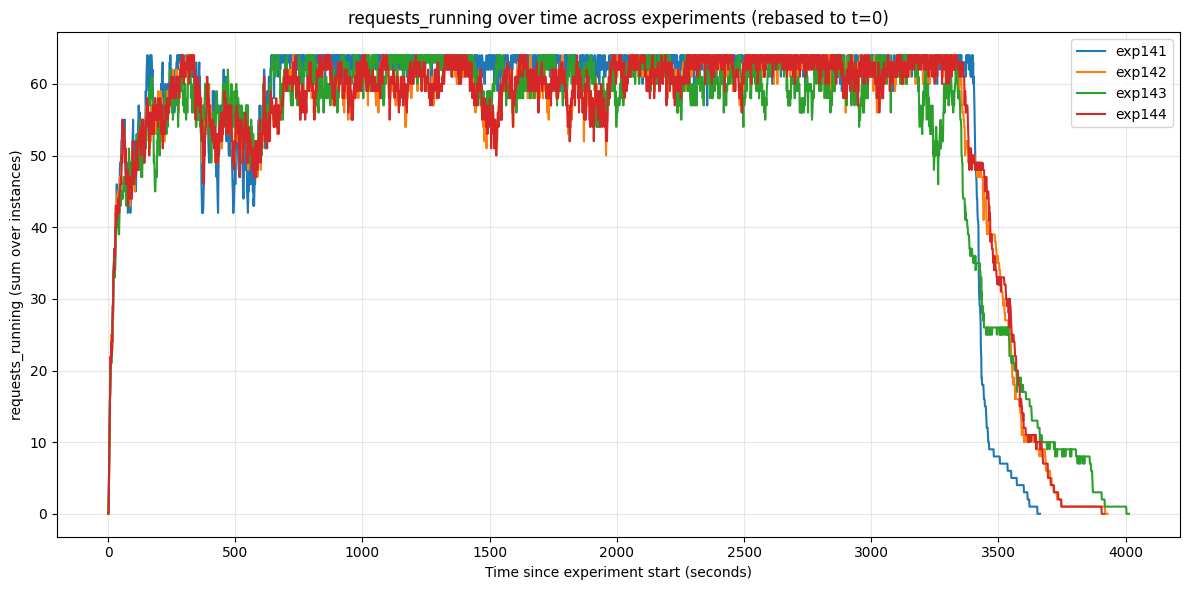

In [10]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
series_ids = [35]

experiments = experiments_from_series(series_ids)

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "request_failure_per_sec"
# metric = "preemptions_per_sec"
# metric = "gpu_kv_cache_usage_frac"
# metric = "cpu_kv_cache_usage_frac"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"

# -----------------------------------------------

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Rebase time: each experiment starts at t=0
    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick
    if agg_mode == "sum":
        series = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances)"

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Token Length Distribution

In [ ]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
series_ids = [35]

experiments = experiments_from_series(series_ids)

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length
# metric = "completion_tokens"  # output length
metric = "total_tokens"       # input + output
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(exp_id=exp_id)
        .sort_values("idx")
        .reset_index(drop=True)
    )

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Token count")
plt.title(f"{metric} over requests across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[141, 142, 143, 144]
../experiments/141/logs.json
../experiments/142/logs.json
../experiments/143/logs.json


In [ ]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
series_ids = [35]

experiments = experiments_from_series(series_ids)

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length distribution
# metric = "completion_tokens"  # output length distribution
metric = "total_tokens"       # input + output distribution
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id)

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    values = pd.to_numeric(df[metric], errors="coerce").dropna()
    if values.empty:
        print(f"Skipping exp{exp_id}: {metric} all NaN")
        continue

    plt.hist(
        values,
        bins=40,
        density=True,     # normalize so experiments are comparable
        alpha=0.35,
        label=f"exp{exp_id}",
    )

plt.xlabel("Token count")
plt.ylabel("Density")
plt.title(f"Request {metric} distribution across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [ ]:
from pathlib import Path
import json
import pandas as pd

# ---- choose experiments ----
# choose which series you want
series_ids = [35]

experiments = experiments_from_series(series_ids)

print(experiments)
# ----------------------------


def count_requests(exp_id, experiments_root="../experiments"):
    exp_dir = Path(experiments_root) / str(exp_id)
    logs_path = exp_dir / "logs.json"

    if not logs_path.exists():
        raise FileNotFoundError(f"logs.json not found for experiment {exp_id}")

    total = 0
    success = 0
    send_failed = 0

    with logs_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            total += 1

            if rec.get("send_failed", False):
                send_failed += 1
            else:
                success += 1

    return {
        "experiment": exp_id,
        "total_requests": total,
        "successful_requests": success,
        "connection_failed_requests": send_failed,
        "success_rate_pct": 100.0 * success / total if total > 0 else 0.0,
        "failure_rate_pct": 100.0 * send_failed / total if total > 0 else 0.0,
    }


rows = []
for exp_id in experiments:
    rows.append(count_requests(exp_id))

df_counts = pd.DataFrame(rows)
df_counts


In [ ]:
from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
series_ids = [35]

experiments = experiments_from_series(series_ids)

print(experiments)
# ----------------------------------------------

percentiles = [0.5, 0.9, 0.99]

# ============================================================
# METRICS ONLY (the ones we added ourselves)
# Choose ONE:
#   "router_only"   -> only router metrics (from :8080 rows)
#   "sidecar_only"  -> only sidecar metrics (from :8200 rows)
#   "all_new"       -> both router + sidecar (two views, same table)
# ============================================================

METRICS_MODE = "all_new"  # <- change me

ROUTER_COLS = [
    "router_queue_length",
    "router_admission_rps",
    "router_outgoing_rps",
]

SIDECAR_COLS = [
    "sidecar_queue_length",
    "sidecar_received_rps",
    "sidecar_completed_rps",
]

MODE_TO_COLS = {
    "router_only": ROUTER_COLS,
    "sidecar_only": SIDECAR_COLS,
    "all_new": ROUTER_COLS + SIDECAR_COLS,
}

if METRICS_MODE not in MODE_TO_COLS:
    raise ValueError(f"Unknown METRICS_MODE={METRICS_MODE!r}. Choose one of: {sorted(MODE_TO_COLS)}")

SELECT_COLS = MODE_TO_COLS[METRICS_MODE]


def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None


def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()


def _summarize_raw_cluster(df: pd.DataFrame, cols: list[str], exp_id: int) -> pd.DataFrame | None:
    """
    Cluster-view: aggregate across instances per tick, then describe across time.
    (No "coverage" output; just raw stats.)
    """
    if df.empty:
        return None

    cols = [c for c in cols if c in df.columns]
    if not cols:
        return None

    # per-tick aggregate across instances
    agg = df.groupby("ts")[cols].sum(min_count=1)

    # drop ticks where everything is missing (prevents NaN-only describe rows)
    agg = agg.dropna(how="all", subset=cols)
    if agg.empty:
        return None

    # if a metric is missing at some ticks, treat as 0 (keeps describe() clean)
    agg[cols] = agg[cols].fillna(0.0)

    # IMPORTANT: prefix ONLY with exp id (no redundant "sidecar_sidecar_*")
    return agg[cols].describe(percentiles=percentiles).add_prefix(f"exp{exp_id}_")


summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    router_df = _subset_by_port(prom, 8080)
    vllm_df = _subset_by_port(prom, 8200)

    if METRICS_MODE == "router_only":
        s = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s)

    elif METRICS_MODE == "sidecar_only":
        s = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s)

    else:  # all_new
        # Router metrics should come from router rows (:8080)
        s_router = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s_router is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s_router)

        # Sidecar metrics should come from vLLM rows (:8200) (where we mapped them)
        s_sidecar = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s_sidecar is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s_sidecar)

comparison = pd.concat(summaries, axis=1) if summaries else pd.DataFrame()
comparison


In [ ]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
series_ids = [35]

experiments = experiments_from_series(series_ids)

print(experiments)
# ----------------------------

# ============================================================
# METRICS ONLY (router + sidecar)
# Choose ONE metric (uncomment exactly one)
# ============================================================

# --- Router metrics ---
metric = "router_queue_length"
# metric = "router_admission_rps"
# metric = "router_outgoing_rps"

# --- Sidecar metrics ---
# metric = "sidecar_queue_length"
# metric = "sidecar_received_rps"
# metric = "sidecar_completed_rps"

# ============================================================
# Which "view" to plot?
#   - "router" : use :8080 rows (ground truth router pod)
#   - "vllm"   : use :8200 rows (broadcast router_* + mapped sidecar_*)
#
# Recommended:
#   - router_* -> view="router"
#   - sidecar_*-> view="vllm"
# ============================================================
view = "router"   # "router" or "vllm"

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"    # "sum" (cluster-level) or "mean" (per-instance average)
# ---------------------------------------------------------

def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

# Auto-pick a sensible default view if user forgets
if view not in ("router", "vllm"):
    raise ValueError("view must be 'router' or 'vllm'")

if metric.startswith("sidecar_") and view == "router":
    print("[WARN] sidecar_* metrics live on vLLM (:8200) rows. Switching view -> 'vllm'.")
    view = "vllm"

if metric.startswith("router_") and view == "vllm":
    print("[NOTE] plotting router_* from vLLM (:8200) rows uses the broadcast values.")
    print("       If you want router ground-truth, set view='router'.")

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Pick the right rows
    if view == "router":
        df = _subset_by_port(prom, 8080)
    else:
        df = _subset_by_port(prom, 8200)

    if df.empty:
        print(f"Skipping exp{exp_id}: no rows for view={view!r}")
        continue

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found in view={view!r}")
        continue

    # Rebase time: each experiment starts at t=0 within this view
    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick (NaNs ignored; if all NaN at tick -> NaN)
    if agg_mode == "sum":
        series = df.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances, view={view})"
    elif agg_mode == "mean":
        series = df.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances, view={view})"
    else:
        raise ValueError("agg_mode must be 'sum' or 'mean'")

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [ ]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os

# ---- choose experiments ----
series_ids = [35]
experiments = experiments_from_series(series_ids)
print(experiments)

# ============================================================
# Choose ONE metric
# ============================================================
# metric = "sidecar_queue_length"
metric = "requests_running"
view = "vllm"  # sidecar_* live on vLLM (:8200)


def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]


# ------------------------------------------------------------
# FIRST PASS: load data + assign server1..serverN per experiment
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)
    df = _subset_by_port(prom, 8200)

    if df.empty or metric not in df.columns:
        continue

    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}

    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)

    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))

# Canonical slot names
canonical_slots = [f"server{i}" for i in range(1, max_servers + 1)]

# ------------------------------------------------------------
# Consistent colors per slot
# ------------------------------------------------------------
cmap = cm.get_cmap("tab20", len(canonical_slots))
color_map = {slot: cmap(i) for i, slot in enumerate(canonical_slots)}

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 5), sharey=True)
if len(experiments) == 1:
    axes = [axes]

for ax, exp_id in zip(axes, experiments):
    df = data_by_exp.get(exp_id)
    if df is None or df.empty:
        ax.grid(True, alpha=0.3)
        continue

    for slot, g in df.groupby("server_slot"):
        if slot not in color_map:
            continue
        g = g.sort_values("t_rel_s")
        ax.plot(
            g["t_rel_s"],
            g[metric],
            color=color_map[slot],
            linewidth=1.5,
        )

    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)
plt.savefig(f"figures/{metric}_per_vllm_queue_comparison.png", dpi=300)

plt.show()
